In [1]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-02-17 19:13:43--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M   475KB/s    in 2.3s    

2026-02-17 19:13:47 (475 KB/s) - ‘input.txt’ saved [1115394/1115394]



In [ ]:
words = open('input.txt').read().split()
vocab = sorted(set(words))
vocab_size = len(vocab)
print(f'{len(words)} total words, {vocab_size} unique words')

202651 total words, 25670 unique words


In [3]:
print(words[:10])

['First', 'Citizen:', 'Before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.']


In [12]:
char = sorted(set(open('input.txt').read()))
vocab_size = len(char)
print(' '.join(char))
print(vocab_size)


   ! $ & ' , - . 3 : ; ? A B C D E F G H I J K L M N O P Q R S T U V W X Y Z a b c d e f g h i j k l m n o p q r s t u v w x y z
65


In [14]:
stoi = { ch:i for i,ch in enumerate(char)}
itos = {i: ch for i, ch in enumerate(char)}

encode = lambda s: [ stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [15]:
print(encode("hii there"))

[46, 47, 47, 1, 58, 46, 43, 56, 43]


In [16]:
print(decode(encode("hii there")))

hii there


In [17]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 195.9 kB/s  0:00:11 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.8/791.8 kB 588.2 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tiktoken]


In [18]:
import tiktoken
encoding = tiktoken.get_encoding("gpt2")
print(encoding.encode("hello world"))

[31373, 995]


In [19]:
import torch

data = torch.tensor(encode(open('input.txt').read()), dtype=torch.long)
print(data.shape, data.dtype)

torch.Size([1115394]) torch.int64


In [20]:
print(data[:100])

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


In [28]:
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]
print(train_data.shape)
print(val_data.shape)

torch.Size([1003854])
torch.Size([111540])


In [ ]:
torch.manual_seed(1337)
batch_size = 4
block_size = 8

def get_batch(split):
    data = train_data if split =='train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return ix,x, y

ix, xb, yb = get_batch('train')

print(ix.shape)  # 4

print('inputs:')
print(xb.shape)   #after stacking 4 sequences of length 8, we get a 4x8 tensor
print(xb)
print('targets:')
print(yb.shape)
print(yb)

torch.Size([4])
inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])


In [29]:
for b in range(batch_size):
    for t in range(block_size):
        context = xb[b, :t+1]
        target = yb[b, t]
        print(f'when input is {context.tolist()} the target: {target}')

when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53, 56, 1, 58, 46] the target: 39
when input is [44, 53, 56, 1, 58, 46, 39] the target: 58
when input is [44, 53, 56, 1, 58, 46, 39, 58] the target: 1
when input is [52] the target: 58
when input is [52, 58] the target: 1
when input is [52, 58, 1] the target: 58
when input is [52, 58, 1, 58] the target: 46
when input is [52, 58, 1, 58, 46] the target: 39
when input is [52, 58, 1, 58, 46, 39] the t

In [34]:
import torch.nn as nn 
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx
    
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)  # (4, 8, vocab_size)
print(loss)


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


In [35]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(m.generate(idx, max_new_tokens=100)[0].tolist()))


SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


In [43]:
batch_size = 32
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
losses = []
steps = []

for step in range(5000):
    _,xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 10 == 0:
        print(f'step {step}: loss {loss.item()}')
    losses.append(loss.item())
    steps.append(step)

step 0: loss 2.5091347694396973
step 10: loss 2.4365627765655518
step 20: loss 2.5229551792144775
step 30: loss 2.4611823558807373
step 40: loss 2.430712938308716
step 50: loss 2.579317092895508
step 60: loss 2.467050552368164
step 70: loss 2.519066333770752
step 80: loss 2.535642385482788
step 90: loss 2.400784969329834
step 100: loss 2.544098138809204
step 110: loss 2.701678991317749
step 120: loss 2.4318220615386963
step 130: loss 2.4375529289245605
step 140: loss 2.6245665550231934
step 150: loss 2.527921676635742
step 160: loss 2.4899215698242188
step 170: loss 2.6078333854675293
step 180: loss 2.5634303092956543
step 190: loss 2.575268507003784
step 200: loss 2.386481761932373
step 210: loss 2.4106523990631104
step 220: loss 2.4269590377807617
step 230: loss 2.546595573425293
step 240: loss 2.611445426940918
step 250: loss 2.501775026321411
step 260: loss 2.529085397720337
step 270: loss 2.6633684635162354
step 280: loss 2.521522283554077
step 290: loss 2.56003999710083
step 300:

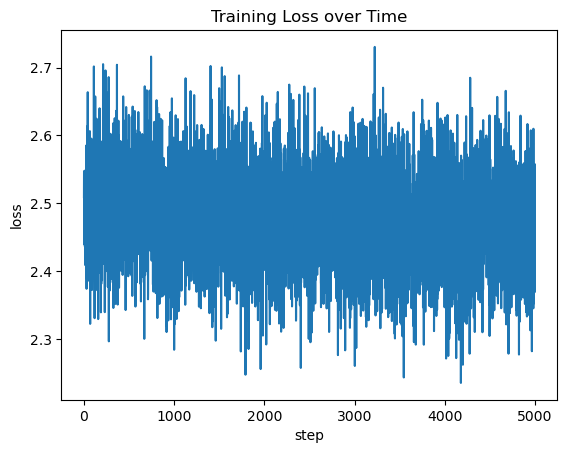

In [44]:
import matplotlib.pyplot as plt
plt.plot(steps, losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training Loss over Time')
plt.show()

In [45]:
print(decode(m.generate(idx, max_new_tokens=500)[0].tolist()))


Filons.

Betis che mereanothal inteprepsere adve, s t pairon whaveg manofiegoofoe:

Nor s to son eat tis f kis:
Wh wan aclad ho yo pe!

AT: arstsit? f ave hisur Sip thame le frouty od.
SAn y-s har terewrulorvek.
FO: e ivatofes his wee, tanald; eangearentanke igro bous t
the.'soucefounker'd f ge t, IAboupa sers HE se.
twike,
Cis rnorusenks, s my avest f as ify.
AReldotos, thenorelimperongo enserat he udeaveceaveandvend howed a w avee thy: ieveavinthod anofeacrthour t, y m d, worinetse hastoforbup
